# Brain2Text24 raw TX heatmap

Visualize the first 64 threshold-crossing channels from the last `brain2text24` session.

This version is intentionally simple:
- point `CACHE_ROOT` at either your local cache or Drive cache
- use the known last-session shard `t12.2022.08.25_sentences`
- plot one trial from `tx.npy` using `time_offsets.npy`


In [9]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Mount Drive and resolve cache/output roots.

from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive')
DEFAULT_CACHE_ROOT_SMOOTHED = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1_smoothed_sigma2p0'
DEFAULT_CACHE_ROOT_RAW = DRIVE_ROOT / 'utah_ssl' / 'data' / 'cache_v1'
OUTPUT_ROOT = DRIVE_ROOT / 'utah_ssl' / 'outputs' / 'ssl_experiments' / 'possm_masked_reconstruction'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('DRIVE_ROOT:', DRIVE_ROOT)
print('DEFAULT_CACHE_ROOT_SMOOTHED exists:', DEFAULT_CACHE_ROOT_SMOOTHED.exists())
print('DEFAULT_CACHE_ROOT_RAW exists:', DEFAULT_CACHE_ROOT_RAW.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)



Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive
DEFAULT_CACHE_ROOT_SMOOTHED exists: True
DEFAULT_CACHE_ROOT_RAW exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/possm_masked_reconstruction


In [10]:
DATASET = "brain2text24"
TRIAL_NUM = 0
N_TX = 64
BIN_SIZE_MS = 20

# Pick one and comment out the other.
CACHE_ROOT = Path("/content/drive/MyDrive/utah_ssl/data/cache_v1")
# CACHE_ROOT = Path("/Users/home/thesis/data/cache_v1")

dataset_dir = CACHE_ROOT / DATASET
shards_dir = dataset_dir / "shards"

assert dataset_dir.exists(), f"Missing dataset directory: {dataset_dir}"
assert shards_dir.exists(), f"Missing shards directory: {shards_dir}"

def is_usable_shard(path: Path) -> bool:
    return path.is_dir() and (path / "tx.npy").exists() and (path / "time_offsets.npy").exists()

sentence_shards = sorted(
    path for path in shards_dir.iterdir() if is_usable_shard(path) and path.name.endswith("_sentences")
)
all_shards = sorted(path for path in shards_dir.iterdir() if is_usable_shard(path))
available_shards = sentence_shards if sentence_shards else all_shards
assert available_shards, f"No usable shard directories found in: {shards_dir}"

shard_dir = available_shards[-1]
SHARD_ID = shard_dir.name
tx_path = shard_dir / "tx.npy"
time_offsets_path = shard_dir / "time_offsets.npy"

assert tx_path.exists(), f"Missing tx file: {tx_path}"
assert time_offsets_path.exists(), f"Missing time offsets file: {time_offsets_path}"

print(f"Using shard: {shard_dir}")
print(f"Usable sentence shards found: {len(sentence_shards)}")
print(f"Usable total shards found: {len(all_shards)}")


Using shard: /content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text24/shards/t12.2022.08.25_sentences


In [11]:
def load_trial_tx(shard_dir: Path, trial_num: int, n_tx: int = 64) -> np.ndarray:
    tx = np.load(shard_dir / "tx.npy", mmap_mode="r")
    time_offsets = np.load(shard_dir / "time_offsets.npy")
    start = int(time_offsets[trial_num])
    stop = int(time_offsets[trial_num + 1])
    return np.asarray(tx[start:stop, :n_tx], dtype=np.float32)


In [12]:
tx = np.load(tx_path, mmap_mode="r")
time_offsets = np.load(time_offsets_path)
n_trials = len(time_offsets) - 1
assert 0 <= TRIAL_NUM < n_trials, f"TRIAL_NUM={TRIAL_NUM} is out of range for shard {SHARD_ID} with {n_trials} trials"

print(f"Session shard: {SHARD_ID}")
print(f"TX array shape: {tx.shape}")
print(f"Trials in shard: {n_trials}")
print(f"Showing trial: {TRIAL_NUM}")


Session shard: t12.2022.08.25_sentences
TX array shape: (164217, 128)
Trials in shard: 610
Showing trial: 0


In [13]:
trial_tx = load_trial_tx(shard_dir, TRIAL_NUM, n_tx=N_TX)
time_s = np.arange(trial_tx.shape[0]) * (BIN_SIZE_MS / 1000.0)

print(f"Shape: {trial_tx.shape}  (time bins x TX channels)")
print(f"Mean crossings/bin across displayed channels: {trial_tx.mean():.3f}")
print(f"Max crossings/bin across displayed channels: {trial_tx.max():.0f}")


Shape: (208, 64)  (time bins x TX channels)
Mean crossings/bin across displayed channels: 0.311
Max crossings/bin across displayed channels: 4


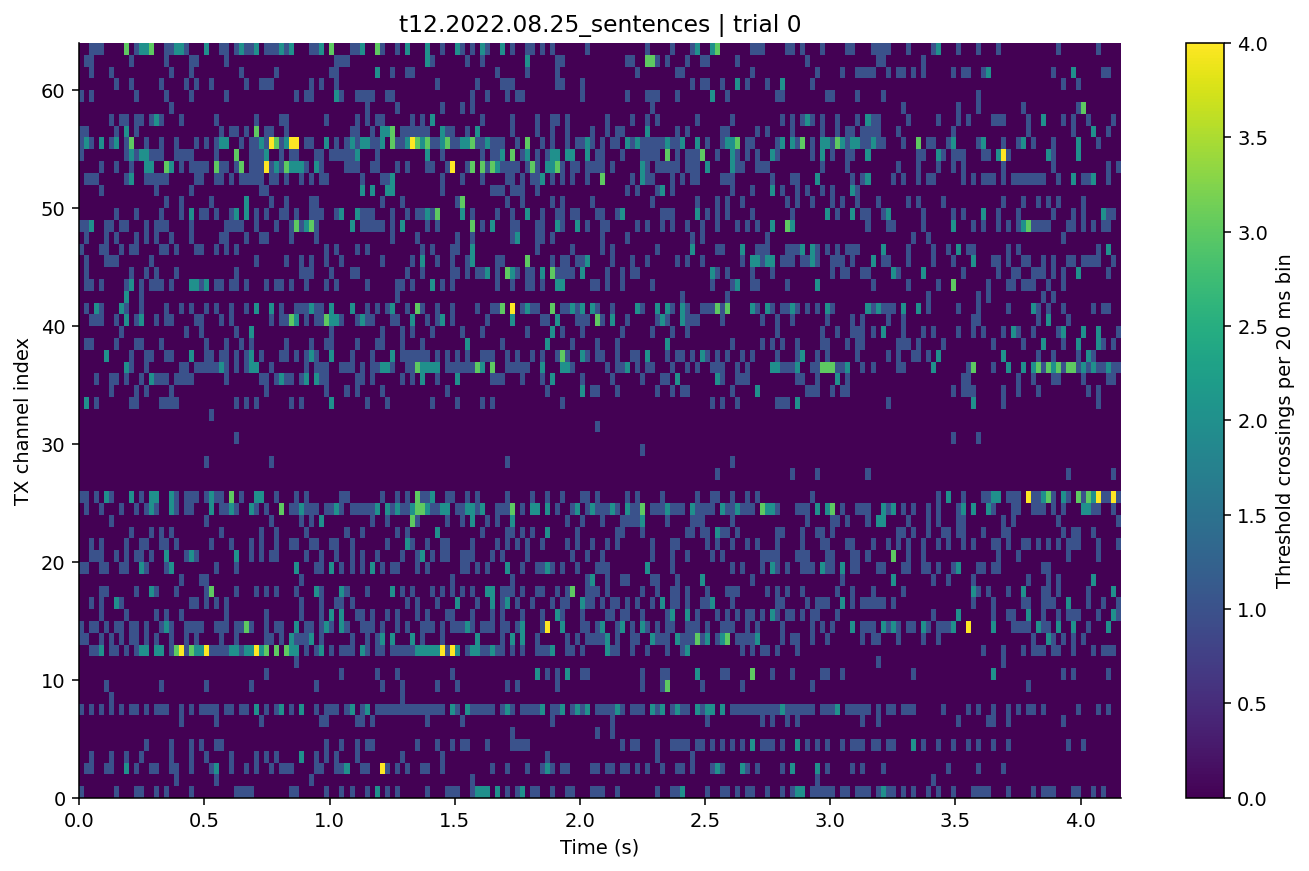

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(
    trial_tx.T,
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    extent=[time_s[0], time_s[-1] + BIN_SIZE_MS / 1000.0, 0, N_TX],
    cmap="viridis",
)
ax.set_title(f"{SHARD_ID} | trial {TRIAL_NUM}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("TX channel index")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Threshold crossings per 20 ms bin")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/utah_ssl/data/cache_v1/brain2text24/shards/t12.2022.08.25_sentences/tx.npy'

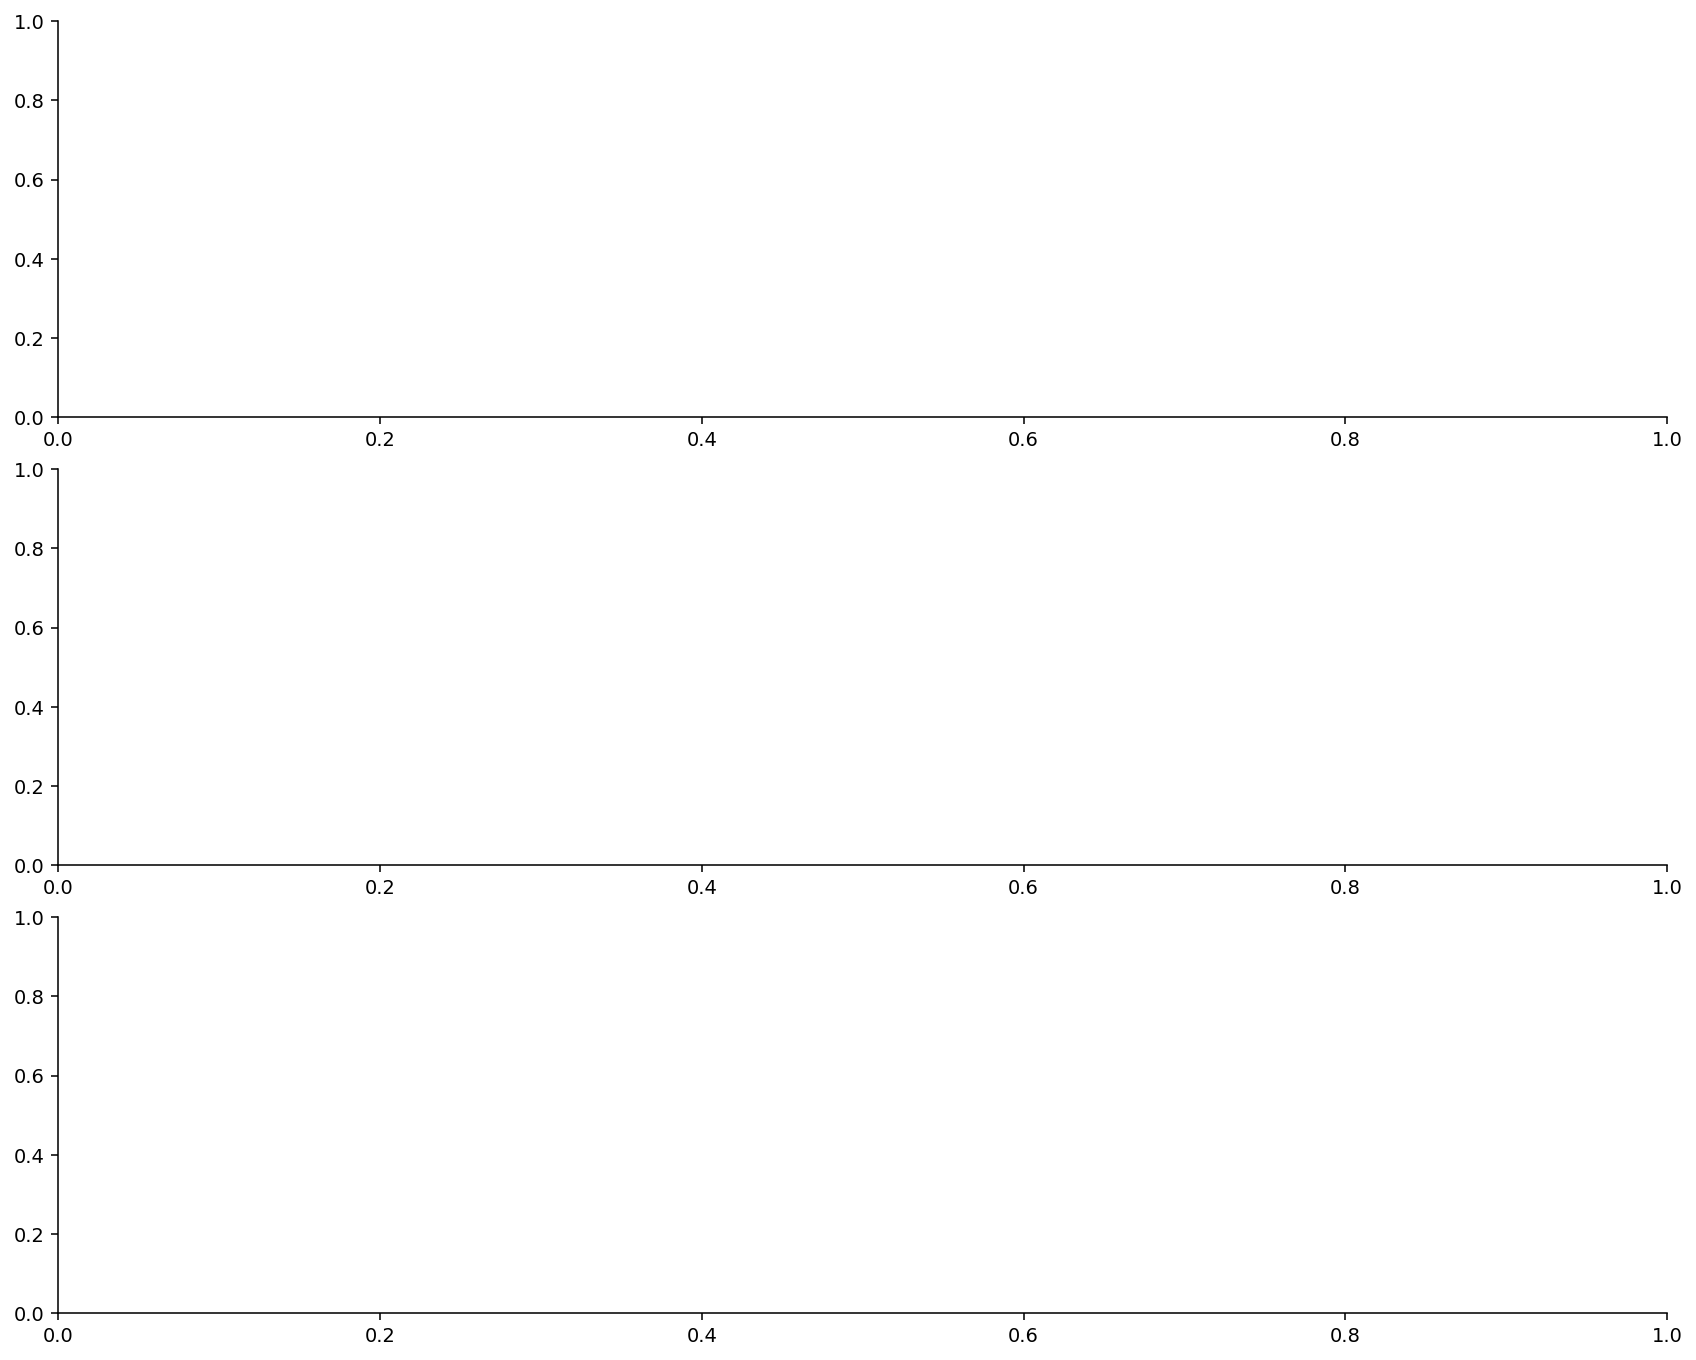

In [15]:
# Optional: compare a few trials quickly by changing TRIALS_TO_SHOW.
TRIALS_TO_SHOW = [0, 1, 2]
TRIALS_TO_SHOW = [trial_num for trial_num in TRIALS_TO_SHOW if 0 <= trial_num < n_trials]
assert TRIALS_TO_SHOW, f"No valid trial indices in TRIALS_TO_SHOW for shard {SHARD_ID}"

fig, axes = plt.subplots(len(TRIALS_TO_SHOW), 1, figsize=(12, 3.2 * len(TRIALS_TO_SHOW)), constrained_layout=True)
if len(TRIALS_TO_SHOW) == 1:
    axes = [axes]

for ax, trial_num in zip(axes, TRIALS_TO_SHOW):
    tx = load_trial_tx(shard_dir, trial_num, n_tx=N_TX)
    im = ax.imshow(tx.T, aspect="auto", interpolation="nearest", origin="lower", cmap="viridis")
    ax.set_ylabel("TX")
    ax.set_title(f"trial {trial_num} | bins={tx.shape[0]}")

axes[-1].set_xlabel("20 ms bins")
fig.colorbar(im, ax=axes, shrink=0.9, label="Threshold crossings per 20 ms bin")
plt.show()
